In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from matplotlib import pyplot as plt
from sklearn import tree

In [ ]:
d=pd.read_csv('/content/drive/MyDrive/AI/survey lung cancer.csv')
d

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


EDA

In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [ ]:
d.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
d.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES
308,M,62,1,1,1,2,1,2,2,2,2,1,1,2,1,YES


In [ ]:
d.shape

(309, 16)

In [ ]:
d.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
d.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


DATA VISUALISATION

--Line chat

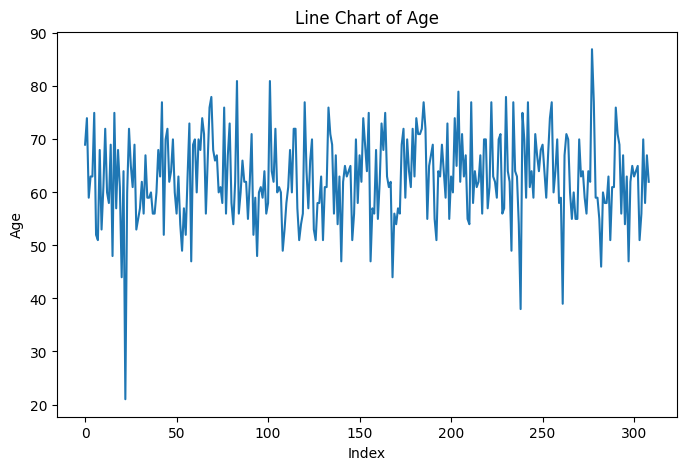

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(d['AGE'])
plt.title("Line Chart of Age")
plt.xlabel("Index")
plt.ylabel("Age")
plt.show()

--Scatter plot

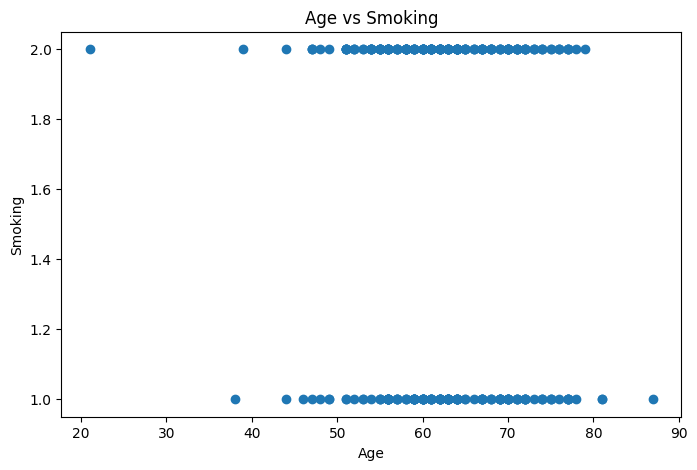

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(d['AGE'], d['SMOKING'])
plt.title("Age vs Smoking")
plt.xlabel("Age")
plt.ylabel("Smoking")
plt.show()

--Bar plot

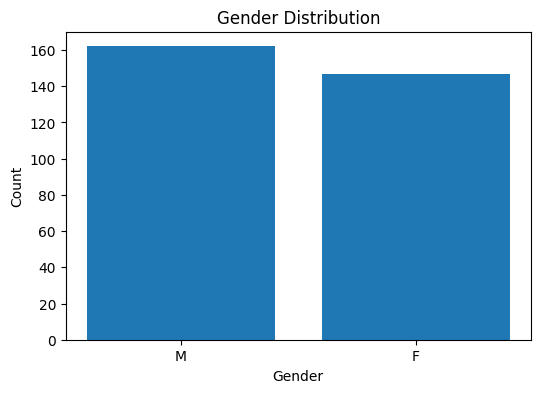

In [ ]:
gender_count = d['GENDER'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_count.index, gender_count.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

--Histogram

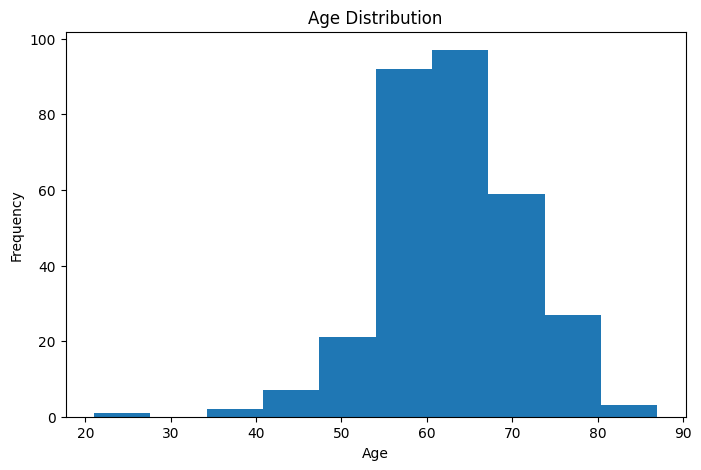

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(d['AGE'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

DATA PREPROCESSING

Handling Missing Values

In [ ]:
d['AGE'] = d['AGE'].fillna(d['AGE'].mean())
d

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='median')
d[['AGE']] = imp.fit_transform(d[['AGE']])
d


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69.0,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74.0,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59.0,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63.0,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63.0,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56.0,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70.0,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58.0,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67.0,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [ ]:
Q1=d['AGE'].quantile(0.25)
Q3=d['AGE'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=d[(d['AGE']<lower_bound)|(d['AGE']>upper_bound)]
outliers


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
22,F,21.0,2,1,1,1,2,2,2,1,1,1,2,1,1,NO
238,F,38.0,1,2,1,1,2,2,2,2,1,2,2,1,2,YES


In [ ]:
from scipy.stats import zscore
z_scores=zscore(d[['AGE']])
d[np.abs(z_scores)>2.5] #z>3 means outlier,range of zscore is -3 to +3

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
22,F,21.0,2,1,1,1,2,2,2,1,1,1,2,1,1,NO
238,F,38.0,1,2,1,1,2,2,2,2,1,2,2,1,2,YES
261,M,39.0,2,1,1,2,1,2,2,2,2,1,2,1,2,YES
277,F,87.0,1,1,1,1,2,2,1,1,1,1,2,1,1,NO


ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
d['GENDER_encoded'] = le_gender.fit_transform(d['GENDER'])
d

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,GENDER_encoded
0,M,69.0,1,2,2,1,1,2,1,2,2,2,2,2,2,YES,1
1,M,74.0,2,1,1,1,2,2,2,1,1,1,2,2,2,YES,1
2,F,59.0,1,1,1,2,1,2,1,2,1,2,2,1,2,NO,0
3,M,63.0,2,2,2,1,1,1,1,1,2,1,1,2,2,NO,1
4,F,63.0,1,2,1,1,1,1,1,2,1,2,2,1,1,NO,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56.0,1,1,1,2,2,2,1,1,2,2,2,2,1,YES,0
305,M,70.0,2,1,1,1,1,2,2,2,2,2,2,1,2,YES,1
306,M,58.0,2,1,1,1,1,1,2,2,2,2,1,1,2,YES,1
307,M,67.0,2,1,2,1,1,2,2,1,2,2,2,1,2,YES,1


In [ ]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(sparse_output=False)
d['GENDER']=one.fit_transform(d[['GENDER']])
d

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,GENDER_encoded
0,0.0,69.0,1,2,2,1,1,2,1,2,2,2,2,2,2,YES,1
1,0.0,74.0,2,1,1,1,2,2,2,1,1,1,2,2,2,YES,1
2,1.0,59.0,1,1,1,2,1,2,1,2,1,2,2,1,2,NO,0
3,0.0,63.0,2,2,2,1,1,1,1,1,2,1,1,2,2,NO,1
4,1.0,63.0,1,2,1,1,1,1,1,2,1,2,2,1,1,NO,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,1.0,56.0,1,1,1,2,2,2,1,1,2,2,2,2,1,YES,0
305,0.0,70.0,2,1,1,1,1,2,2,2,2,2,2,1,2,YES,1
306,0.0,58.0,2,1,1,1,1,1,2,2,2,2,1,1,2,YES,1
307,0.0,67.0,2,1,2,1,1,2,2,1,2,2,2,1,2,YES,1


In [ ]:
d=pd.get_dummies(d,columns=['GENDER'],drop_first=True)
d

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,GENDER_encoded,GENDER_1.0
0,69.0,1,2,2,1,1,2,1,2,2,2,2,2,2,YES,1,False
1,74.0,2,1,1,1,2,2,2,1,1,1,2,2,2,YES,1,False
2,59.0,1,1,1,2,1,2,1,2,1,2,2,1,2,NO,0,True
3,63.0,2,2,2,1,1,1,1,1,2,1,1,2,2,NO,1,False
4,63.0,1,2,1,1,1,1,1,2,1,2,2,1,1,NO,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,56.0,1,1,1,2,2,2,1,1,2,2,2,2,1,YES,0,True
305,70.0,2,1,1,1,1,2,2,2,2,2,2,1,2,YES,1,False
306,58.0,2,1,1,1,1,1,2,2,2,2,1,1,2,YES,1,False
307,67.0,2,1,2,1,1,2,2,1,2,2,2,1,2,YES,1,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_lung_cancer = LabelEncoder()
d['LUNG_CANCER_encoded'] = le_lung_cancer.fit_transform(d['LUNG_CANCER'])

y = d['LUNG_CANCER_encoded']

X = d.drop(columns=['LUNG_CANCER', 'LUNG_CANCER_encoded', 'GENDER_encoded'])

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(x_test)

In [ ]:
from sklearn import metrics
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9354838709677419


In [ ]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

Decision Tree Confusion Matrix:
[[ 5  2]
 [ 4 82]]


In [ ]:
from sklearn.tree import export_graphviz
import graphviz

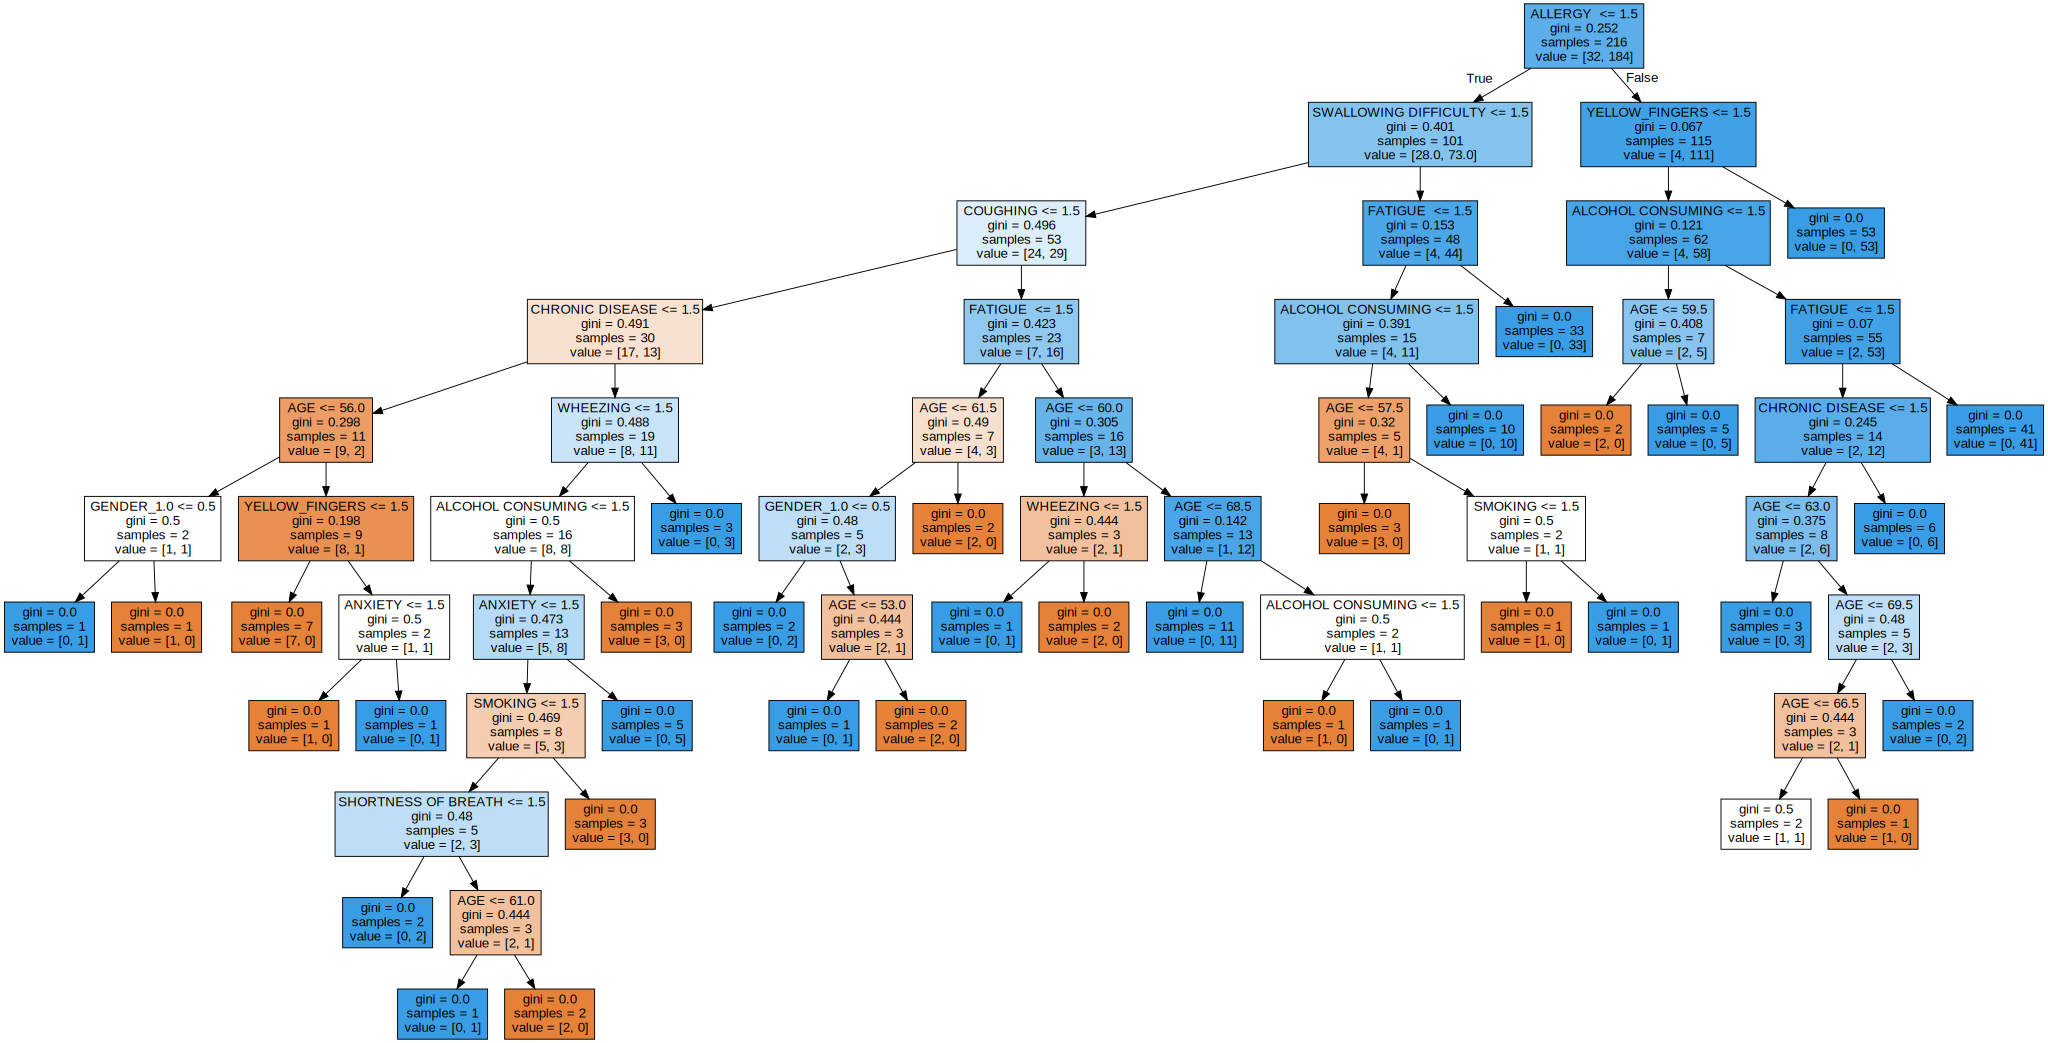

In [ ]:
graphviz.Source(export_graphviz(clf, feature_names=X.columns.tolist(), filled=True))